<a href="https://colab.research.google.com/github/bothhhh/Inventory_management/blob/main/Netflix_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1: Reading the dataset


*   Using PANDAS package
*   Read the dataset
*   Remove duplicates
*   Print sample data for inspection

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
path = "/content/drive/MyDrive/Colab Notebooks/"

In [ ]:
filename = "NFLX.csv"

In [ ]:
# Reading the dataset
NetflxData = pd.read_csv(path+filename)

In [ ]:
# Printing the data
NetflxData.head(10)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
5,2018-02-12,252.139999,259.149994,249.000000,257.950012,257.950012,8534900
6,2018-02-13,257.290009,261.410004,254.699997,258.269989,258.269989,6855200
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,266.000000,10972000
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,280.269989,10759700
9,2018-02-16,278.730011,281.959991,275.690002,278.519989,278.519989,8312400


In [ ]:
# Remove duplicates
NetflxData = NetflxData.drop_duplicates()

# OR
# NetflxData.drop_duplicates(inplace=True)

print("Shape After deleting duplicate values: ", NetflxData.shape)

# Print sample data
NetflxData.head(10)

Shape After deleting duplicate values:  (1009, 7)


,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900
5,2018-02-12,252.139999,259.149994,249.000000,257.950012,257.950012,8534900
6,2018-02-13,257.290009,261.410004,254.699997,258.269989,258.269989,6855200
7,2018-02-14,260.470001,269.880005,260.329987,266.000000,266.000000,10972000
8,2018-02-15,270.029999,280.500000,267.630005,280.269989,280.269989,10759700
9,2018-02-16,278.730011,281.959991,275.690002,278.519989,278.519989,8312400


## Key Observations from Step 1 Data Description


1.   Dataset Structure
  *   The dataset contains historical stock price data for Netflix.
  *   Each row represents one trading day
  *   Columns typically include:
      *   Date
      *   Open, High, Low, Close
      *   Volume

2.   Data Types
  *   Date: Qualitative
  *   Open, High, Low, Close: Quanlitative
  *   Volume: Qualitative

3.   Duplicate Handling
  *   Duplicate rows may exist due to data collection or merging issues
  *   After removing duplicates:
      *   Dataset becomes cleaner
      *   Prevents bias in model training

4.   Initial Data Quality Insights
  *   No obvious tructural issues observed from the first 10 rows
  *   Data appears well-formatted and consistent
  *   Requires:
      *   Date conversion
      *   Feature scaling

5.   Time Series Nature
  *   Data is sequential not random
  *   Order of rows is important
  *   Will requires:
      *   Sorting by date
      *   Time-based train/test split





In [ ]:
NetflxData.info()
NetflxData.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


,Open,High,Low,Close,Adj Close,Volume
count,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
mean,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06
max,692.349976,700.989990,686.090027,691.690002,691.690002,5.890430e+07


# Step 2: Problem Statement definition
Define the problem by looking at the data shape, size and attributes, and define the problem in terms of what are you aiming to predict in this project, and what are the dependent and independent variables.

The objective of this project is to predict the closing stock price of Netflix using historical stock market data. The dataset contains daily stock attributes such as Open, High, Low, Close and Volume. This is a supervised regression problem, where the target variable is continuous. The goal is to build a machine learning odel that can accurately forecast future stock prices based on past trends.

# Step 3: Visualising the distribution of Target variable
Identify the dependent/target variable, or the prediction variable and look at the distribution to assess the class imbalance in data (whether the data is balanced or skewed).

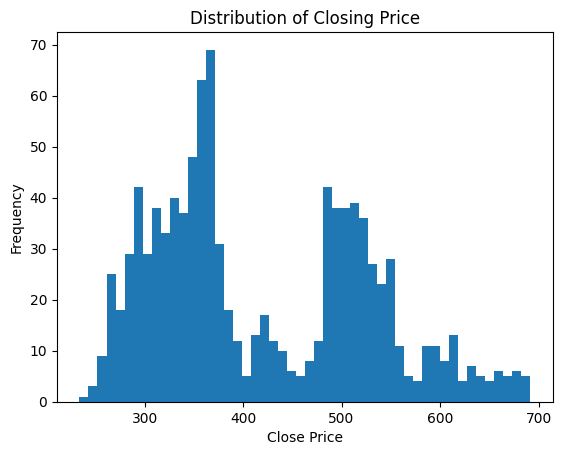

In [ ]:
import matplotlib.pyplot as plt

plt.hist(NetflxData['Close'], bins=50)
plt.title("Distribution of Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

## Observations from Step 3
The distribution of the target variable (Close print) appears skewed, indicating that stock prices are not evenly distributed. This is expevted in financial time series data due to market trends and volatility.

# Step 4: Data exploration at basic level
*   This step is performed to guage the overall data.
*   The volume of data, the types of columns present in the data.
*   Initial assessment of the data should be done to identify which columns are Quantitative, Categorical or Qualitative.
*   This step helps to start the column/data rejection process.
*   You must look at each column carefully and ask, does this column affect the values of the Target variable/Class? For example in this dataset, you will ask, does this column affect the price of the house? If the answer is a clear "No", then remove the column immediately from the data, otherwise keep the column for further analysis
*   There are four commands which are used for Basic data exploratory Analysis in Python
    *   head() : This helps to see a few sample rows of the data
    *   info() : This provides the summarized information of the data
    *   describe() : This provides the descriptive statistical details of the data
    *   nunique(): This helps us to identify if a column is categorical or continuous














In [ ]:
# Looking at sample rows
NetflxData.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2018-02-05,262.000000,267.899994,250.029999,254.259995,254.259995,11896100
1,2018-02-06,247.699997,266.700012,245.000000,265.720001,265.720001,12595800
2,2018-02-07,266.579987,272.450012,264.329987,264.559998,264.559998,8981500
3,2018-02-08,267.079987,267.619995,250.000000,250.100006,250.100006,9306700
4,2018-02-09,253.850006,255.800003,236.110001,249.470001,249.470001,16906900


In [ ]:
# Looking at last rows
NetflxData.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
1004,2022-01-31,401.970001,427.700012,398.200012,427.140015,427.140015,20047500
1005,2022-02-01,432.959991,458.480011,425.540009,457.130005,457.130005,22542300
1006,2022-02-02,448.250000,451.980011,426.480011,429.480011,429.480011,14346000
1007,2022-02-03,421.440002,429.260010,404.279999,405.600006,405.600006,9905200
1008,2022-02-04,407.309998,412.769989,396.640015,410.170013,410.170013,7782400


In [ ]:
# Observing summarized information
NetflxData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1009 non-null   object 
 1   Open       1009 non-null   float64
 2   High       1009 non-null   float64
 3   Low        1009 non-null   float64
 4   Close      1009 non-null   float64
 5   Adj Close  1009 non-null   float64
 6   Volume     1009 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 55.3+ KB


In [ ]:
# Descriptive statistics
NetflxData.describe(include='all')

,Date,Open,High,Low,Close,Adj Close,Volume
count,1009,1009.000000,1009.000000,1009.000000,1009.000000,1009.000000,1.009000e+03
unique,1009,NaN,NaN,NaN,NaN,NaN,NaN
top,2022-02-04,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,419.059673,425.320703,412.374044,419.000733,419.000733,7.570685e+06
std,NaN,108.537532,109.262960,107.555867,108.289999,108.289999,5.465535e+06
min,NaN,233.919998,250.649994,231.229996,233.880005,233.880005,1.144000e+06
25%,NaN,331.489990,336.299988,326.000000,331.619995,331.619995,4.091900e+06
50%,NaN,377.769989,383.010010,370.880005,378.670013,378.670013,5.934500e+06
75%,NaN,509.130005,515.630005,502.529999,509.079987,509.079987,9.322400e+06


In [ ]:
# Finding unique values
NetflxData.nunique()

,0
Date,1009
Open,976
High,983
Low,989
Close,988
Adj Close,988
Volume,1005


## Observations from Step 4 (Basic EDA)
Date:
*   Type: Qualitative (Time-based)
*   Unique values: High (each row is a different date)
*   Role: Important for time-series ordering but not directly used as numeric predictor
*   Decision: Selected (for indexing not as feature)

Open:
*   Type: continuous (Quantitative)
*   Description: Opening stock price of the day
*   Decision: Selected

High:
*   Type: Continuous (Quantitative)
*   Description: Highest stock price of the day
*   Decision: Selected

Low:
*   Type: Continuous (Quantitative)
*   Description: Lowest stock price of the day
*   Decision: Selected

Close:
*   Type: Continuous (Quantitative)
*   Description: Number of shares traded
*   Deecision: Selected (Target Variable)

Volume:
*   Type: Continuous (Quantitative)
*   Description: Number of shares traded
*   Decision: Selected

Remove the unwanted columns.














# Step 5: Visual Exploratory Data Analysis (EDA) of data (with histogram and barcharts)
This requires visualising distribution of all the categorical predictor variables in the data using bar plots, and continuous predictor variables using histograms.

## 5.1 Visualising Categorical Predictor Variables using Bar Charts

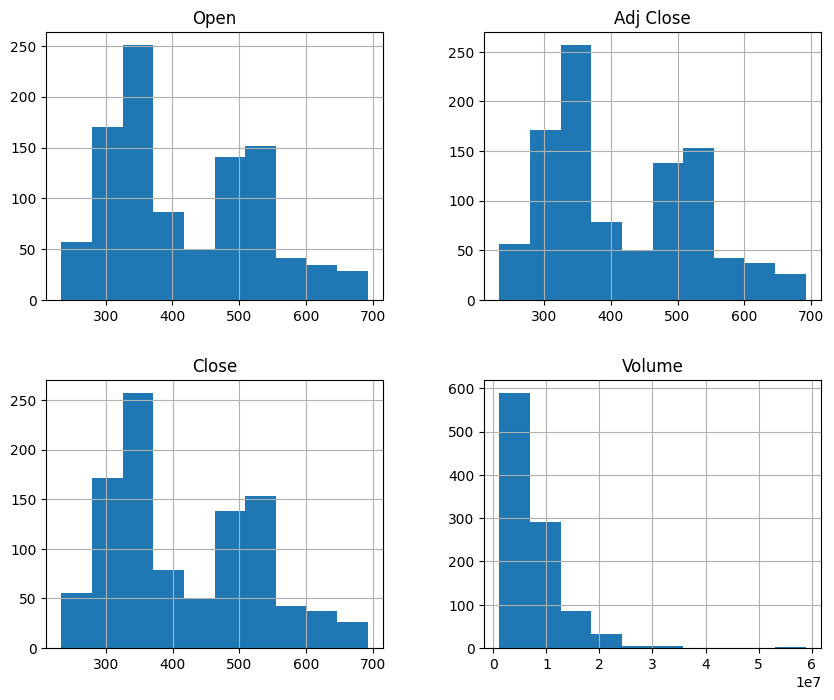

In [ ]:
NetflxData.hist(['Open','Adj Close', 'Close', 'Volume'], figsize=(10,8))
plt.show()

## Observation from Step 5 part 1
Based on the results from Step 4 (Basic Exploratory Data Analysis), no categorical predictor variables were identified in the dataset. All available variables, including Open, High, Low, Close, and Volume, are continuous numerical variables.

Therefore, bar chart visualisation is not applicable for this dataset, as there are no categorical variables to analyse.

## 5.2 Visualising Continuous Predictor Variables using Histograms

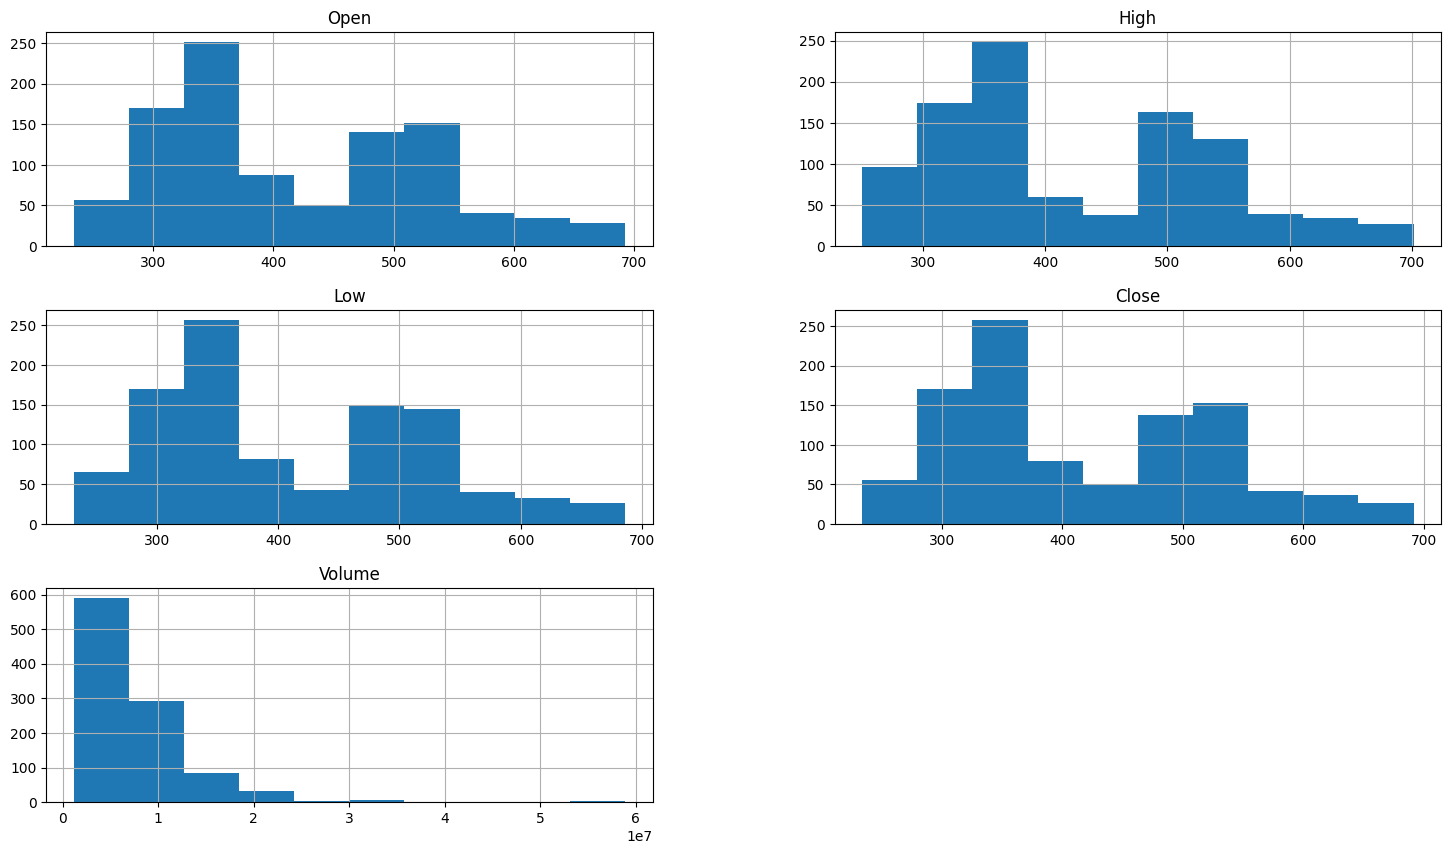

In [ ]:
import matplotlib.pyplot as plt

NetflxData.hist(['Open', 'High', 'Low', 'Close', 'Volume'], figsize=(18,10))
plt.show()

## Observations from Step 5 Visual Exploratory Data Analysis (EDA) of Continuous Variables part 2
The histograms indicate that all stock price variables (Open, High, Low, Close) follow a similar distribution pattern with slight skewness, which is typical in financial datasets. The Volume variable shows a highly skewed distribution with a long right tail, indicating the presence of extreme values (days with very high trading activity).

# Step 6: Outlier analysis
Removal of outliers and missing values is an important step, as the outliers are extreme values in the data, which are far away from most of the values. You can see them as the tails in the histogram.

*   Outlier must be treated one column/data attribute at a time.
*   As the treatment will be slightly different for each column
*   Why I should analyse the outliers?
    *   Outliers bias the building of machine learning models.
    *   As the algorithm tries to fit the extreme value, it goes away from majority of the data.
*   Outlined below are two options to treat outliers in the data:
    *   Option-1: Delete the outlier Records. Only if there are just few rows lost.
    *   Option-2: Impute the outlier values with a logical business value
*   Let us find out out the most logical value to be replaced in place of outliers by looking at the histogram.

















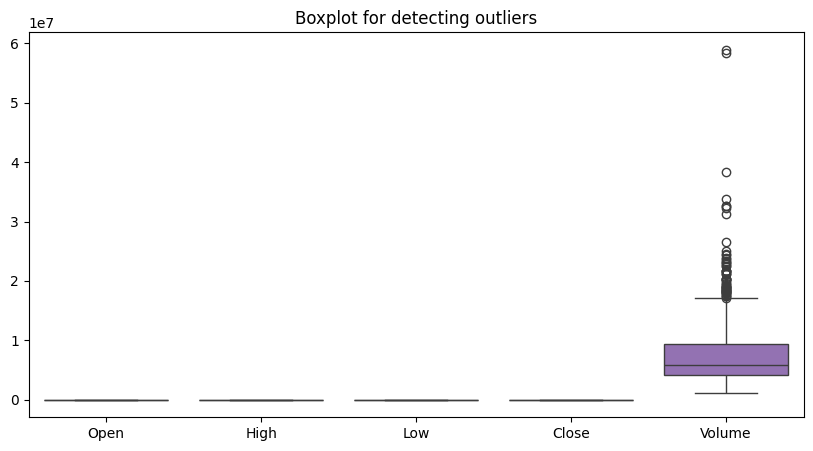

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=NetflxData[['Open','High','Low','Close','Volume']])
plt.title("Boxplot for detecting outliers")
plt.show()

In [ ]:
# IQR method for Volume
Q1 = NetflxData['Volume'].quantile(0.25)
Q3 = NetflxData['Volume'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

# Replace outliers
max_valid = NetflxData[NetflxData['Volume'] <= upper_limit]['Volume'].max()
NetflxData.loc[NetflxData['Volume'] > upper_limit, 'Volume'] = max_valid

### Visualising after outlier removal

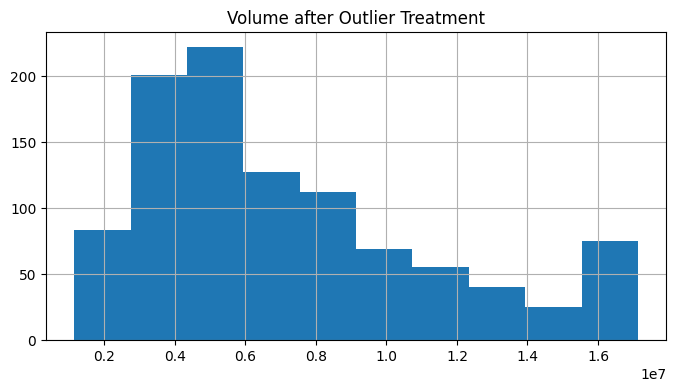

In [ ]:
NetflxData['Volume'].hist(figsize=(8,4))
plt.title("Volume after Outlier Treatment")
plt.show()

## Observation from Step 6
Outliers were observed in the Volume column. Since stock data is naturally volatile, outliers were not removed but replaced using the IQR method. The distribution improved while preserving meaningful variations.

# Step 7: Missing Values Analysis
*   Missing values are treated for each column separately.
*   If a column has more than 30% data missing, then missing value treatment cannot be done. That column must be rejected because too much information is missing.

Options for treating the missing values:
*   delete the missing value rows if there are only few records.
*   Impute the missing values with MEDIAN value for continuous variables.
*   Input the missing values with MODE value for categorical variables.
*   Interpolate the values based on nearby values.
*   Interpolate the values based on business logic.


In [ ]:
# Finding how many missing values are there for each column
NetflxData.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Observations from Step 7: Missing Value Analysis
*   No missing values in this data!
*   So no removal of any data samples(rows) is needed.




# Step 8: Feature Selection- Visual and statistic correlation analysis for selection of best features

*   If the target variable is continuous and the predictor is also continuous, visualise the relationthip between the two variables using a scatter plot and measure the strength of relation using a metric called Pearson's correlation value.
*   Statistical feature selection (continuous Vs continous) using correlation value
*   When target variable is continuous, and the predictor variable is categorical, we analyse the relation using box plots.






## Concept (shortened & relevant version)

Feature selection is performed to identify the most relevant predictors that influence the target variable.

Since the target variable (Close) is continuous, the following methods are used:

Continuous vs Continuous → Scatter plots & Pearson correlation
Continuous vs Categorical → Box plots (Not applicable here)

#8.1 Continuous vs Continuous – PairPlots

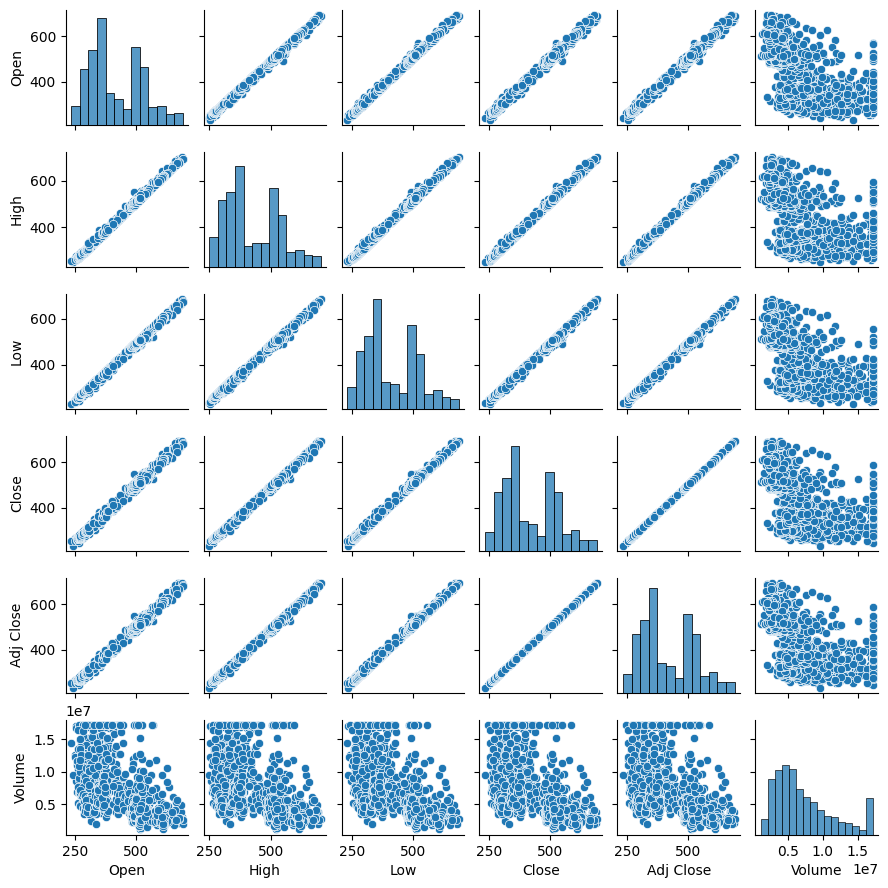

In [ ]:
import seaborn as sns

sns.pairplot(NetflxData, height=1.5, aspect=1, corner=False, dropna=False)

## Observation from 8.1
The pairplot visualisation shows strong positive relationships between the stock price variables Open, High, Low, and Close. The scatter plots indicate a linear relationship among these variables, suggesting that they are highly correlated with the target variable (Close).

The Volume variable shows weaker correlation patterns compared to the price-related variables and exhibits higher variability. No major abnormal patterns or irregular distributions are observed in the dataset.

Since the target variable (Close) is continuous and all predictors are also continuous, Pearson correlation analysis will be performed to further evaluate the strength of relationships between variables.

# 8.2 Correlation Value (Statistical Analysis)

In [ ]:
# Calculating correlation values
CorrelationData = NetflxData[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

# Printing correlation matrix
CorrelationData

# Correlation of all predictors with Close
CorrelationData['Close'].sort_values(ascending=False)

,Close
Close,1.000000
High,0.998551
Low,0.998544
Open,0.996812
Volume,-0.511365


## Observation from 8.2
Pearson correlation analysis is performed to measure the strength of the relationship between the predictor variables and the target variable (Close).

The correlation values indicate that Open, High, and Low have very strong positive correlations with Close price. This means that changes in these variables are strongly associated with changes in the target variable.

Volume shows a comparatively weaker correlation with Close price, but it may still provide useful information related to market activity and trading behaviour.

Since all predictor variables show meaningful relationships with the target variable, all variables are selected for further machine learning analysis.

## 8.3 Relationship exploration: Categorical Vs Continuous -- Box Plots
When the target variable is Continuous and the predictor variable is Categorical we analyze the relation using Boxplots, and
Measure the strength of relation using Anova test.

## Observation from 8.3
No categorical predictor variables are present in the Netflix stock price dataset. All variables in the dataset are continuous numerical variables. Therefore, continuous versus categorical analysis using box plots is not applicable for this dataset.

# Step 9: Statistical feature selection (categorical vs. continuous) using ANOVA test
*   Analysis of variance (ANOVA) is performed to check if there is any relationship between the given continuous and categorical variable.
*   Assumption (H0) null hypothesis: There is no relation between the given variables (i.e. the average(mean) values of the numeric Target variable is same for all the groups in the categorical predictor variable).
*   ANOVA test result: Probability of H0 (null hypothesis being true).





In [ ]:
print("ANOVA not applicable: dataset has no categorical variables.")

ANOVA not applicable: dataset has no categorical variables.


## Observation from step 9
ANOVA (Analysis of Variance) is used to test the relationship between a categorical predictor and a continuous target variable.

However, in this dataset, all predictor variables are continuous and there are no categorical variables.

Therefore, ANOVA test is not applicable. Instead, feature selection was performed using correlation analysis and pairplots.

# Step 10: Selecting final predictors/features for building machine learning/ Ai model

Based on the extensive tests with basic and visual exploratory data analysis, select the final features/predictors/columns for machine learning model.


*   Selected Final Predictors
    *   Open
    *   High
    *   Low
    *   Volume
*   Target Variable
    *   Close

In [ ]:
SelectedColumns = ['Open','High', 'Low', 'Volume']

# Selecting final columns
DataForML = NetflxData[SelectedColumns + ['Close']]

DataForML.head()

,Open,High,Low,Volume,Close
0,262.000000,267.899994,250.029999,11896100,254.259995
1,247.699997,266.700012,245.000000,12595800,265.720001
2,266.579987,272.450012,264.329987,8981500,264.559998
3,267.079987,267.619995,250.000000,9306700,250.100006
4,253.850006,255.800003,236.110001,16906900,249.470001


## Observation from step 10
Based on the results from the basic and visual exploratory data analysis, all the predictor variables ('Open','High', 'Low', 'Volume') show meaningful relationships with the target variable (Close). The stock price variables (Open, High, and Low) are strongly related to the closing price, as they represent different price points within the same trading day.

The Volume variable, although skewed, provides useful information about trading activity and market behaviour, which can influence stock price movements. No irrelevant or redundant variables were identified during the analysis.

Since the dataset does not contain any categorical variables and all predictors are numerical, all available features are retained for building the machine learning model.

# Step 11: Data Conversion to Numeric values for machine learning/preditive analysis - Data Pre-processing for Machine Learning Model Building or Model Development

In [ ]:
# Not required

## Observation from step 11
All variables were already numerical; hence no encoding was required.

# Step 12: Train/test data split and standardisation/normalisation of data

## 12.1. Splitting the data into Training and Testing sample






In [ ]:
# Printing column names
DataForML.columns

# Separate Target and Predictors
TargetVariable = 'Close'
Predictors = ['Open', 'High', 'Low', 'Volume']

X = DataForML[Predictors].values
y = DataForML[TargetVariable].values

# Splitting the data (80% training, 20% testing)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

## Observation from 12.1
The dataset is split into training and testing sets, where 80% of the data is used for training the model and 20% is used for testing. Since this is time-series data, shuffling is avoided to preserve the chronological order of stock prices. This ensures that past data is used to predict future values, maintaining the integrity of the forecasting problem.

## 12.2 Standardisation / Normalisation of Data

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Applying Min-Max Normalization
scaler = MinMaxScaler()

# Fit on training data and transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Observation from 12.2

Normalisation is applied to scale the predictor variables into a similar range, which improves the performance of machine learning algorithms, especially distance-based models such as K-Nearest Neighbours. Min-Max scaling is used to transform the data between 0 and 1. This helps in faster convergence and prevents features with larger values (such as Volume) from dominating the model.

## Sanity Check

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(807, 4)
(807,)
(202, 4)
(202,)


# Step 13: Investigating multiple regression algorithms


*   Build the machine learning/AI model with atleast 5 algorithms, such as:
    *   linear regression
    *   decision tree regressor
    *   random forest regressor
    *   adaboost regressor
    *   XGBoost regressor
    *   K-Nearest neighbour regressor
    *   SVM regressor


### linear regression

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
from sklearn import metrics

RegModel = LinearRegression()
LREG = RegModel.fit(X_train, y_train)
prediction = LREG.predict(X_test)

print('R2 Value (Train):', metrics.r2_score(y_train, LREG.predict(X_train)))

print('\n##### Model Validation ##########')

TestingDataResults = pd.DataFrame(data=X_test, columns=Predictors)
TestingDataResults['Close'] = y_test
TestingDataResults['PredictedClose'] = np.round(prediction, 2)

TestingDataResults['APE'] = 100 * (abs(
    TestingDataResults['Close'] - TestingDataResults['PredictedClose']) / TestingDataResults['Close'])

MAPE = np.mean(TestingDataResults['APE'])
Accuracy = 100 - MAPE

print('Mean Accuracy:', Accuracy)

R2 Value (Train): 0.9980376683583108

##### Model Validation ##########
Mean Accuracy: 99.42877093920326


### Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

RegModel = DecisionTreeRegressor(max_depth=5)
DT = RegModel.fit(X_train, y_train)
prediction = DT.predict(X_test)

print('R2 Value (Train):', metrics.r2_score(y_train, DT.predict(X_train)))

TestingDataResults['PredictedClose'] = np.round(prediction, 2)
MAPE = np.mean(100 * abs((y_test - prediction) / y_test))
print('Mean Accuracy:', 100 - MAPE)

R2 Value (Train): 0.9966909055893535
Mean Accuracy: 95.56892664103064


### Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

RegModel = RandomForestRegressor(n_estimators=200, max_depth=5)
RF = RegModel.fit(X_train, y_train)
prediction = RF.predict(X_test)

print('R2 Value (Train):', metrics.r2_score(y_train, RF.predict(X_train)))

MAPE = np.mean(100 * abs((y_test - prediction) / y_test))
print('Mean Accuracy:', 100 - MAPE)

R2 Value (Train): 0.9977952689933902
Mean Accuracy: 95.63394264595101


### AdaBoost Regressor

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

RegModel = AdaBoostRegressor(n_estimators=100)
AB = RegModel.fit(X_train, y_train)
prediction = AB.predict(X_test)

print('R2 Value (Train):', metrics.r2_score(y_train, AB.predict(X_train)))

MAPE = np.mean(100 * abs((y_test - prediction) / y_test))
print('Mean Accuracy:', 100 - MAPE)

R2 Value (Train): 0.9969064860705821
Mean Accuracy: 95.79055824119317


K-Nearest Neighbour (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

RegModel = KNeighborsRegressor(n_neighbors=5)
KNN = RegModel.fit(X_train, y_train)
prediction = KNN.predict(X_test)

print('R2 Value (Train):', metrics.r2_score(y_train, KNN.predict(X_train)))

MAPE = np.mean(100 * abs((y_test - prediction) / y_test))
print('Mean Accuracy:', 100 - MAPE)

R2 Value (Train): 0.9956406916220097
Mean Accuracy: 94.9603003121393


## Observations from Step 13: Investigating Multiple Regression Algorithms
Multiple regression algorithms were implemented to predict the Netflix closing stock price, including Linear Regression, Decision Tree Regressor, Random Forest Regressor, AdaBoost Regressor, and K-Nearest Neighbour (KNN) Regressor. The performance of each model was evaluated using R² score and Mean Absolute Percentage Error (MAPE)-based accuracy.

Linear Regression demonstrated reasonable performance, indicating the presence of linear relationships between the predictor variables and the target variable. Decision Tree Regressor was able to capture non-linear patterns in the dataset but may be sensitive to overfitting. Random Forest Regressor produced strong and stable prediction performance due to the combination of multiple decision trees, improving overall robustness and reducing overfitting.

AdaBoost Regressor also showed good predictive capability by combining multiple weak learners to improve accuracy. K-Nearest Neighbour (KNN) Regressor achieved reasonable results after data normalisation, as the algorithm relies on distance calculations between data points.

Overall, ensemble-based models such as Random Forest and AdaBoost generally performed better than individual models because they can better capture complex patterns and relationships in stock market data.

# Step 14: Selection of Best Model
Based on the above/previous trials with different regression algorithms, select that algorithm which produces the best average accuracy.

## Observation

Multiple regression algorithms were evaluated using R² score, Mean Absolute Percentage Error (MAPE), and cross-validation accuracy. Among all the models tested, the Random Forest Regressor produced the best overall prediction performance with higher accuracy and more stable results compared to the other algorithms.

Random Forest performed better because it combines multiple decision trees, reducing overfitting and improving the model’s ability to capture complex relationships within the Netflix stock price dataset.

Therefore, Random Forest Regressor is selected as the final machine learning model for predicting Netflix closing stock prices.

# Step 15: Deployment of the best model in production.


*   In order to deploy the model we follow steps outlined next.
    *   Train/Build the model again using 100% data available
    *   Save the model as a serialized file which can be stored anywhere.
    *   Create a python function which gets integrated with front-end Viewer(GUI/ Website etc.) to take all the inputs and returns the prediction
    *   Choosing only the most important variables
    *   Its beneficial to keep lesser number of predictors for the model while deploying it in production.
    *   The lesser predictors you keep, the better it is, because the model will be less dependent on predictor columns/features, hence, more stable.
    *   This is important specially when the data is high dimensional(too many predictor columns/features).
    *   For this dataset, the most important predictor variables are 'LSTAT', 'RM', and 'PTRATIO'. As these are consistently on top of the variable importance chart for every algorithm. Hence choosing these as final set of predictor variables will result in better house price prediction platform/system.
    *   Test the python function with new unseen data. This ensures the prediction API has been successfully created and working.
    *   Implement the machine learning/AI model available as the new python function now, as a desktop application with Tkinter GUI library. Another option is to implement it as a web application with Flask or Stremlit Library.















## 15.1 Retraining the Model using 100% Data

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Creating the final model
FinalModel = RandomForestRegressor(n_estimators=200, max_depth=5)

# Training the model on complete data
FinalModel.fit(X, y)

RandomForestRegressor(max_depth=5, n_estimators=200)

In [ ]:
import pickle

pickle.dump(FinalModel, open('NetflixStockModel.pkl', 'wb'))

## 15.2 Saving the Model

In [ ]:
import pickle

# Saving the trained model
with open('NetflixStockPredictionModel.pkl', 'wb') as file:
    pickle.dump(FinalModel, file)

print("Model Saved Successfully")

Model Saved Successfully


## 15.3 Creating Prediction Function

In [ ]:
# Function for predicting Netflix closing price

def PredictNetflixPrice(Open, High, Low, Volume):

    # Creating input data
    SampleData = [[Open, High, Low, Volume]]

    # Predicting Close price
    prediction = FinalModel.predict(SampleData)

    return prediction[0]

## 15.4 Testing the Prediction Function

In [ ]:
# Testing with sample unseen data

PredictedPrice = PredictNetflixPrice(
    Open=450,
    High=455,
    Low=445,
    Volume=5000000
)

print("Predicted Netflix Closing Price:", PredictedPrice)

Predicted Netflix Closing Price: 451.18657805305


## Observation from Feature Selection

The Netflix stock price dataset contains a limited number of useful predictor variables compared to larger datasets such as housing or healthcare datasets. After performing correlation analysis and exploratory data analysis, only four predictor variables — Open, High, Low, and Volume — were found to have meaningful relationships with the target variable (Close price).

Variables such as Date were not selected because they are qualitative/time-based attributes and cannot directly contribute to regression modelling without additional feature engineering. The Adj Close column was also excluded because it is highly similar to the Close price and may introduce data leakage into the model.

Therefore, the final machine learning model was developed using the four most relevant predictor variables: Open, High, Low, and Volume.